# MADRL Training Notebook

This notebook configures, trains, evaluates, and visualizes multi-agent energy storage experiments. Run the cells from top to bottom.


In [10]:
from pathlib import Path
import sys

try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except Exception:
    pass

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "configs").exists():
    project_root = project_root.parent
if not (project_root / "configs").exists():
    raise RuntimeError("Could not locate the project root.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
project_root


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


WindowsPath('D:/GithubProject/MADRL_ESS')

In [11]:
from common.experiment_notebook_utils import (
    build_runner,
    evaluate_runner,
    get_lstm_artifact_root,
    get_madrl_checkpoint_root,
    inspect_runner_io,
    summarize_cfg,
)
from common.torch_runtime import configure_torch_runtime, describe_device
from configs import compose_experiment_config
from evaluation.plots import plot_last_k_episodes_price_action_soc
from evaluation.reward_plots import plot_reward_decomposition


In [12]:
# Notebook layer: keep only experiment-specific knobs here.
# Use profiles for training-scale templates; keep only run-specific toggles in the notebook.
profile = "debug"                    # base/debug/fast_train: training-scale template
algorithm = "MADDPG"                 # MADDPG | MATD3: RL algorithm family
model_family = "mlp"                 # mlp | transformer | graph: policy/critic backbone
reward_type = "composite"            # composite | sparse: reward design
future_horizon = 24                   # planning horizon in 15-min steps; 24 = 6 hours
sequence_source = "truth"            # truth | lstm: sequence features come from oracle data or LSTM
forecast_type = "perfect" if sequence_source == "truth" else "lstm"
observation_profile = "simbench"     # observation preset for local/sequence feature defaults
local_features = None                 # None -> use the preset from observation_profile
sequence_features = None              # None -> use the preset from observation_profile
vec_env_type = "dummy"               # dummy = single-process batch; subproc = multi-process env workers
runtime_mode = "performance"         # performance | strict_reproducibility
device_request = None                 # None -> auto-select CUDA, otherwise force a specific device
require_cuda = False                  # True -> fail fast if CUDA is not available
seed = 0
n_eval_episodes = 2                   # extra evaluation episodes after training
reward_plot_window = 20               # reward moving-average window
n_recent_episodes_to_plot = 2         # how many recent episodes to draw as trajectories


In [ ]:
cfg = compose_experiment_config(
    profile=profile,
    algorithm=algorithm,
    model_family=model_family,
    reward_type=reward_type,
    observation_profile=observation_profile,
    forecast_type=forecast_type,
    vec_env_type=vec_env_type,
    local_features=local_features,
    sequence_features=sequence_features,
    data_dir=project_root / "data",
    runtime_mode=runtime_mode,
    seed=seed,
    require_cuda=require_cuda,
)

runtime_state = configure_torch_runtime(
    cfg,
    device=device_request,
    seed=seed,
    require_cuda=require_cuda,
)
device_info = describe_device(runtime_state)

# Notebook overrides: keep only task-specific settings here.
# Put reusable training-scale settings such as batch_size, buffer_size, and num_envs back into profiles.
cfg.data.dataset_type = "csv_prosumer"               # dataset pipeline used to build episodes
cfg.train.num_envs = 4
cfg.train.train_episodes = 300
cfg.env.num_agents = 3                                 # number of agents; should match the dataset columns
cfg.env.episode_limit = 96 * 2                         # environment steps per episode; currently 2 days
cfg.env.future_horizon = future_horizon                # horizon used by sequence observations and reward look-ahead
cfg.obs.local_features = ["time", "price", "load", "pv", "soc"]
cfg.obs.sequence_features = ["price", "load", "pv"]
cfg.forecast.target_signals = ["price", "load", "pv"]
if forecast_type == "lstm":
    cfg.forecast.history_window = max(cfg.forecast.history_window, 96 * 7)
    cfg.forecast.lstm_artifact_root = get_lstm_artifact_root(project_root)

summary = summarize_cfg(cfg)
summary["device_info"] = device_info
summary


{'algo': 'MADDPG',
 'batch_size': 128,
 'data_dir': 'D:\\GithubProject\\MADRL_ESS\\data',
 'dataset_type': 'csv_prosumer',
 'device': 'cuda:0',
 'env_type': 'energy_storage',
 'episode_limit': 192,
 'expected_completed_episodes_floor': 8,
 'forecast': 'perfect',
 'future_horizon': 24,
 'local_features': ['time', 'price', 'load', 'pv', 'soc'],
 'max_train_steps': None,
 'model_family': 'mlp',
 'num_envs': 4,
 'obs_builder_type': 'default',
 'parallel_rollout_iterations': 384,
 'partial_steps_per_env_at_stop': 0,
 'resolved_train_steps': 1536,
 'reward': 'composite',
 'runtime_mode': 'performance',
 'seed': 0,
 'sequence_features': ['price', 'load', 'pv'],
 'train_budget_source': 'train_episodes * episode_limit',
 'train_episodes': 8,
 'vec_env': 'dummy'}


{'algo': 'MADDPG',
 'env_type': 'energy_storage',
 'dataset_type': 'csv_prosumer',
 'obs_builder_type': 'default',
 'model_family': 'mlp',
 'reward': 'composite',
 'forecast': 'perfect',
 'local_features': ['time', 'price', 'load', 'pv', 'soc'],
 'sequence_features': ['price', 'load', 'pv'],
 'vec_env': 'dummy',
 'num_envs': 4,
 'batch_size': 128,
 'train_episodes': 8,
 'episode_limit': 192,
 'future_horizon': 24,
 'max_train_steps': None,
 'resolved_train_steps': 1536,
 'parallel_rollout_iterations': 384,
 'expected_completed_episodes_floor': 8,
 'partial_steps_per_env_at_stop': 0,
 'train_budget_source': 'train_episodes * episode_limit',
 'device': 'cuda:0',
 'runtime_mode': 'performance',
 'seed': 0,
 'data_dir': 'D:\\GithubProject\\MADRL_ESS\\data',
 'device_info': {'device': 'cuda:0',
  'cuda_available': True,
  'name': 'NVIDIA GeForce RTX 5080',
  'capability': '12.0',
  'total_memory_gb': 15.92}}

In [14]:
runner = build_runner(cfg, seed=seed, env_name="NotebookTrain", number=1)
plot_reward_fn = runner.env_evaluate.reward_fn
print("Observation schema =", cfg.runtime.observation_schema)
print("Observation layout =", cfg.runtime.observation_layout)
print("Action dim =", cfg.runtime.action_dim)


Observation schema = {'local': (3, 6), 'adjacency': (3, 3), 'price_seq': (25,), 'load_seq': (3, 25), 'pv_seq': (3, 25)}
Observation layout = {'local': {'group': 'local', 'scope': 'per_agent', 'dim': 6, 'fields': ['time', 'price', 'load', 'pv', 'soc']}, 'adjacency': {'group': 'graph', 'scope': 'shared', 'dim': 3, 'fields': ['adjacency']}, 'price_seq': {'feature_name': 'price', 'group': 'sequence', 'scope': 'shared', 'dim': 1, 'description': '价格窗口，支持预测器替换', 'shape': (25,)}, 'load_seq': {'feature_name': 'load', 'group': 'sequence', 'scope': 'per_agent', 'dim': 1, 'description': '每个 agent 的负荷窗口', 'shape': (3, 25)}, 'pv_seq': {'feature_name': 'pv', 'group': 'sequence', 'scope': 'per_agent', 'dim': 1, 'description': '每个 agent 的光伏窗口', 'shape': (3, 25)}}
Action dim = 1


In [15]:
sanity_summary = inspect_runner_io(runner, cfg)
sanity_summary


{'action_batch_shape': (4, 3, 1),
 'action_dim': 1,
 'actor_action_shape': (1, 3, 1),
 'critic_shape': (1, 1),
 'done_shape': (4, 3, 1),
 'info_keys': ['available_signals',
               'base_net_load',
               'battery_capacity_kwh',
               'e_bat',
               'e_bat_req',
               'e_max',
               'e_min',
               'episode_done',
               'load',
               'mu_next',
               'mu_t',
               'net_load',
               'p_lower',
               'p_max',
               'p_upper',
               'price',
               'pv',
               'r_bonus',
               'r_inc',
               'r_pbrs',
               'r_pen',
               'r_soc',
               'reward',
               'soc_max',
               'soc_min',
               'soc_next',
               'soc_t',
               't'],
 'next_obs_shapes': {'adjacency': (4, 3, 3),
                     'load_seq': (4, 3, 25),
                     'local': (4, 3, 6),
  

{'observation_schema': {'local': (3, 6),
  'adjacency': (3, 3),
  'price_seq': (25,),
  'load_seq': (3, 25),
  'pv_seq': (3, 25)},
 'observation_layout': {'local': {'group': 'local',
   'scope': 'per_agent',
   'dim': 6,
   'fields': ['time', 'price', 'load', 'pv', 'soc']},
  'adjacency': {'group': 'graph',
   'scope': 'shared',
   'dim': 3,
   'fields': ['adjacency']},
  'price_seq': {'feature_name': 'price',
   'group': 'sequence',
   'scope': 'shared',
   'dim': 1,
   'description': '价格窗口，支持预测器替换',
   'shape': (25,)},
  'load_seq': {'feature_name': 'load',
   'group': 'sequence',
   'scope': 'per_agent',
   'dim': 1,
   'description': '每个 agent 的负荷窗口',
   'shape': (3, 25)},
  'pv_seq': {'feature_name': 'pv',
   'group': 'sequence',
   'scope': 'per_agent',
   'dim': 1,
   'description': '每个 agent 的光伏窗口',
   'shape': (3, 25)}},
 'action_dim': 1,
 'rollout_obs_shapes': {'local': (4, 3, 6),
  'adjacency': (4, 3, 3),
  'price_seq': (4, 25),
  'load_seq': (4, 3, 25),
  'pv_seq': (4, 3, 2

In [16]:
episodes_completed = runner.run()
print("训练完成 episode 数 =", episodes_completed)
runner.perf_summary


Training:   0%|          | 0/384 [00:00<?, ?iters/s]

训练完成 episode 数 = 8


{'seed': 0,
 'runtime_mode': 'performance',
 'device': 'cuda:0',
 'total_wall_time_s': 4.546040499999435,
 'action_time_s': 0.3629982000020391,
 'env_step_time_s': 0.1718645999862929,
 'update_time_s': 3.932985200026451,
 'update_calls': 353,
 'steps_per_sec': 337.87644434760114,
 'avg_action_ms_per_iter': 0.9453078125053102,
 'avg_env_ms_per_iter': 0.4475640624643044,
 'avg_update_ms_per_call': 11.141601133219408}

Mean evaluation reward = -2289.877425123006


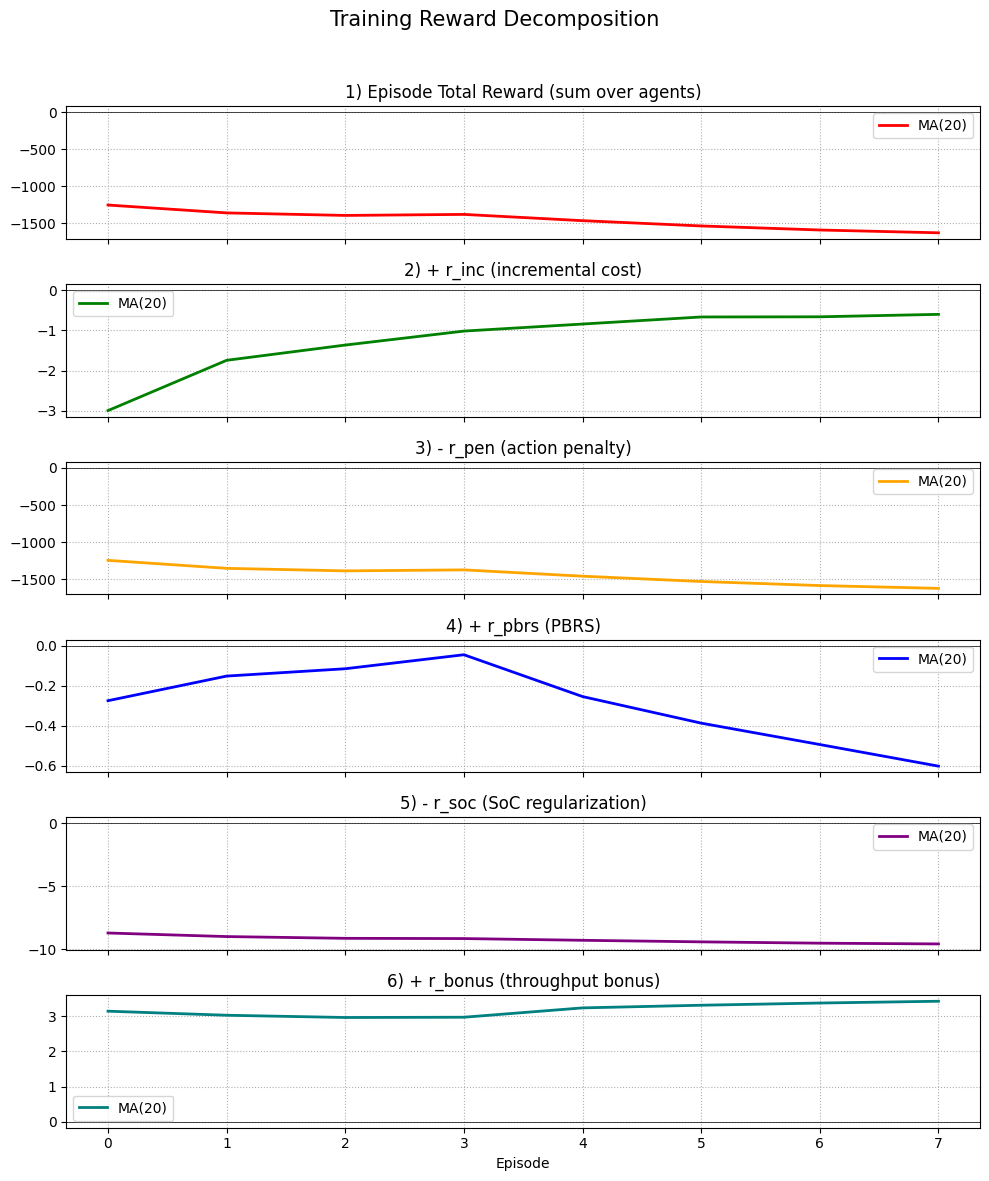

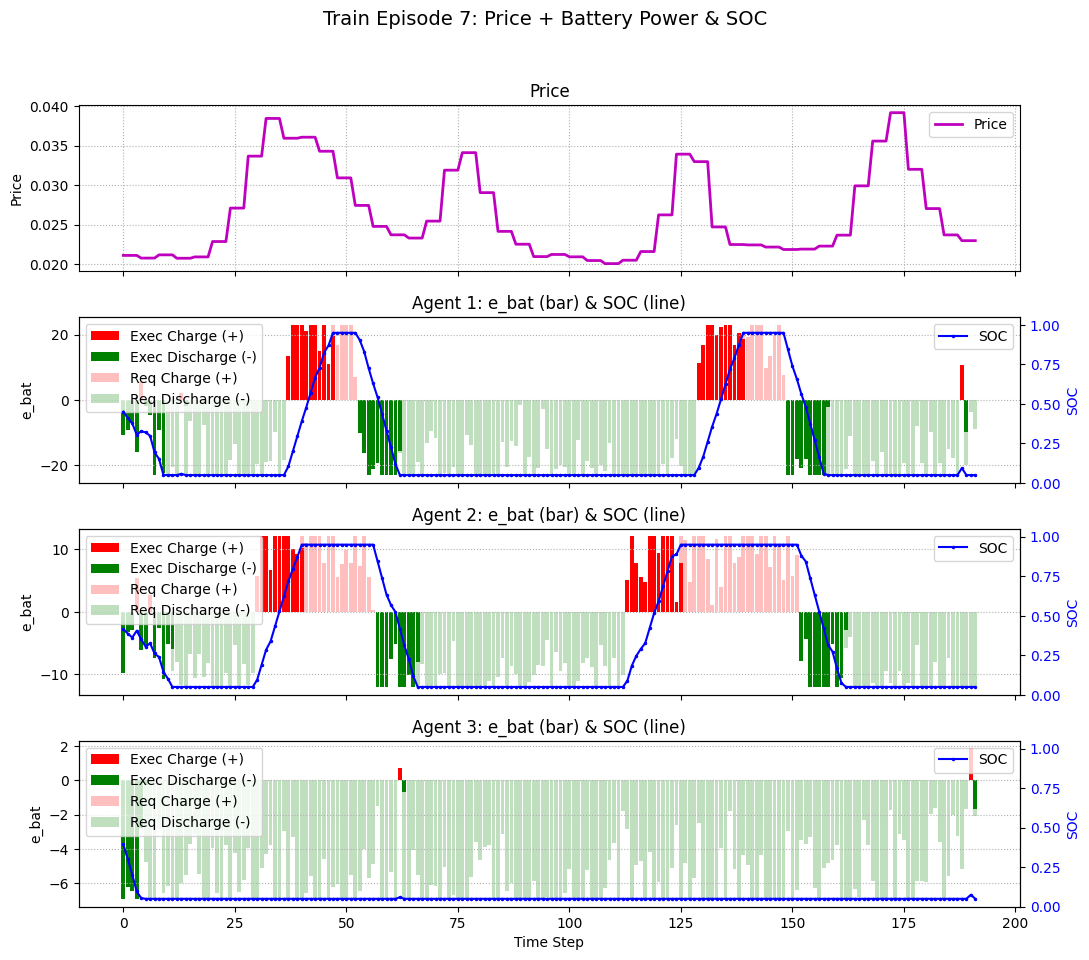

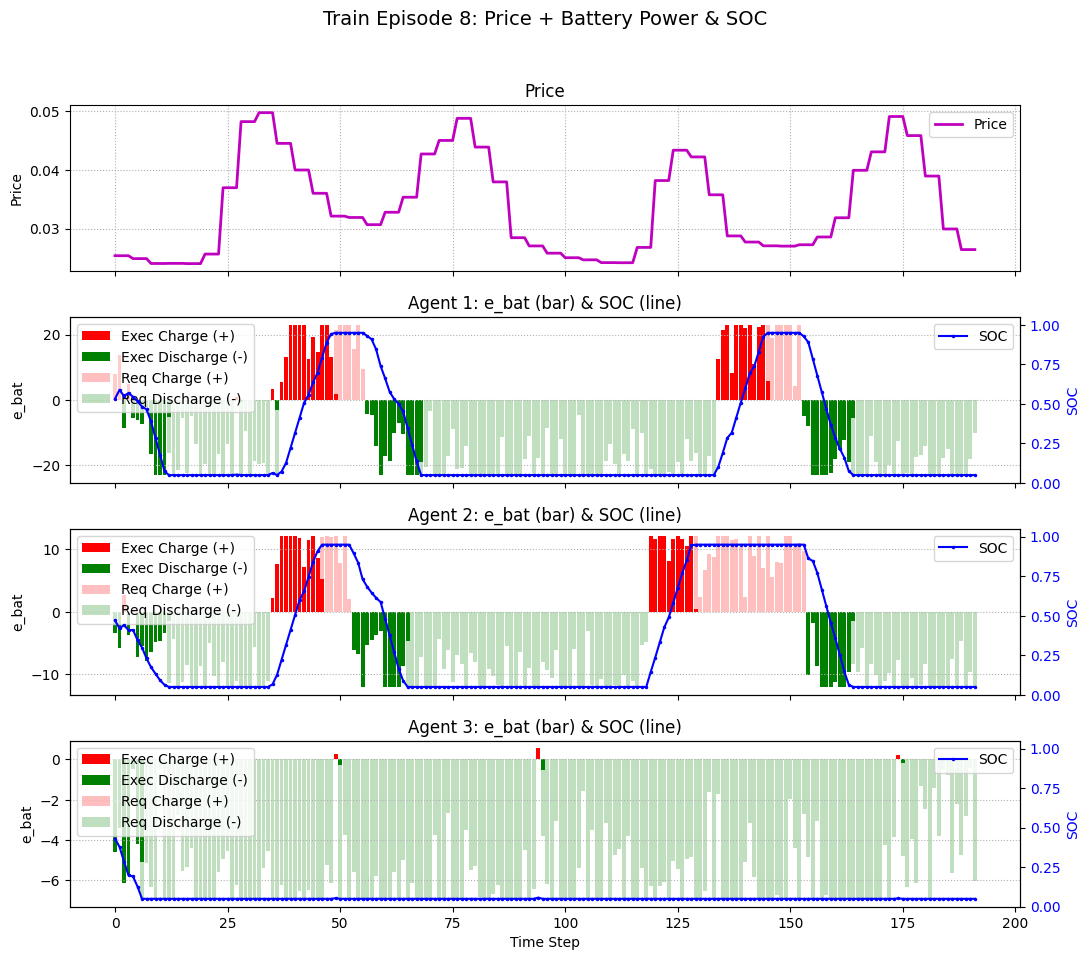

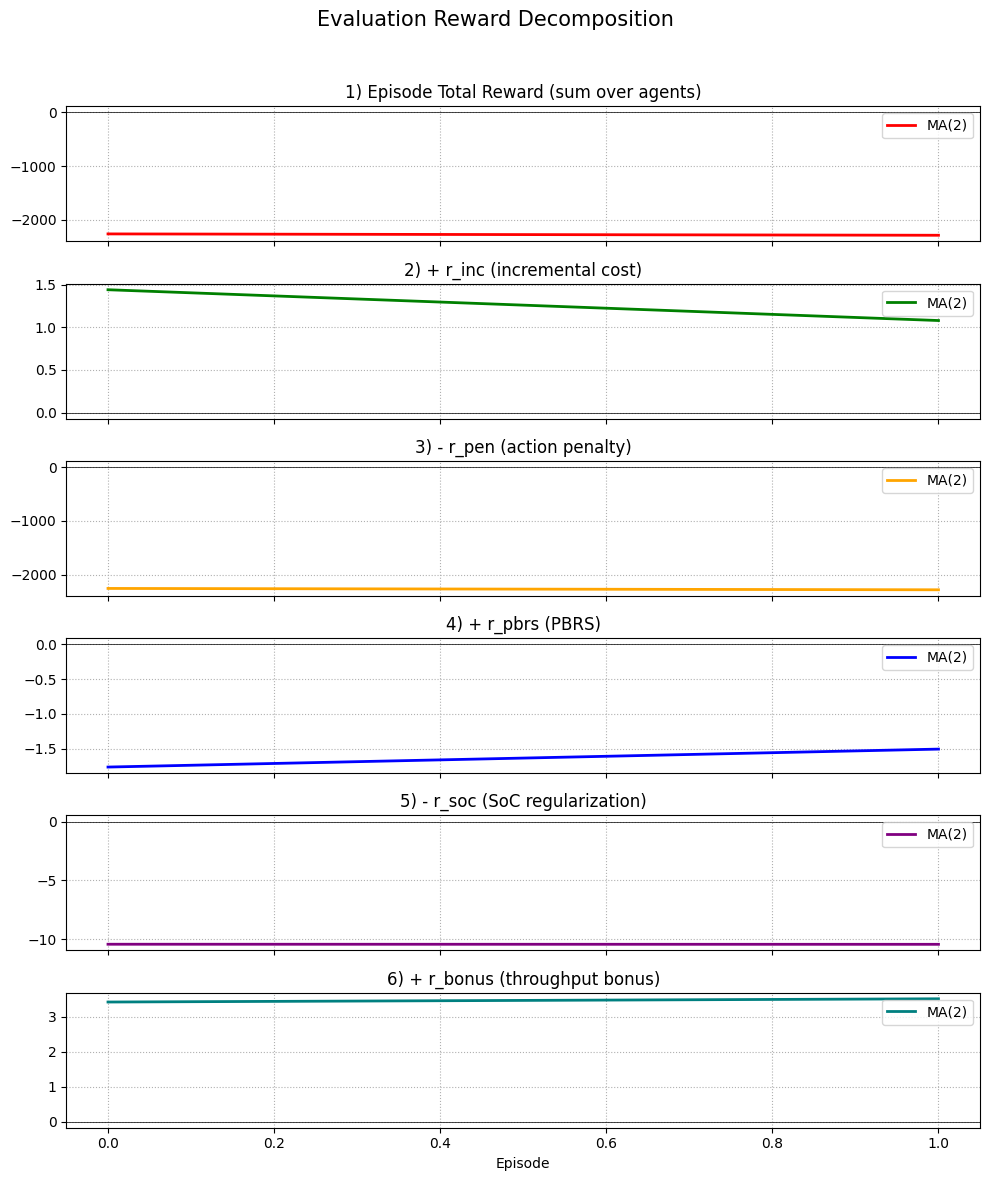

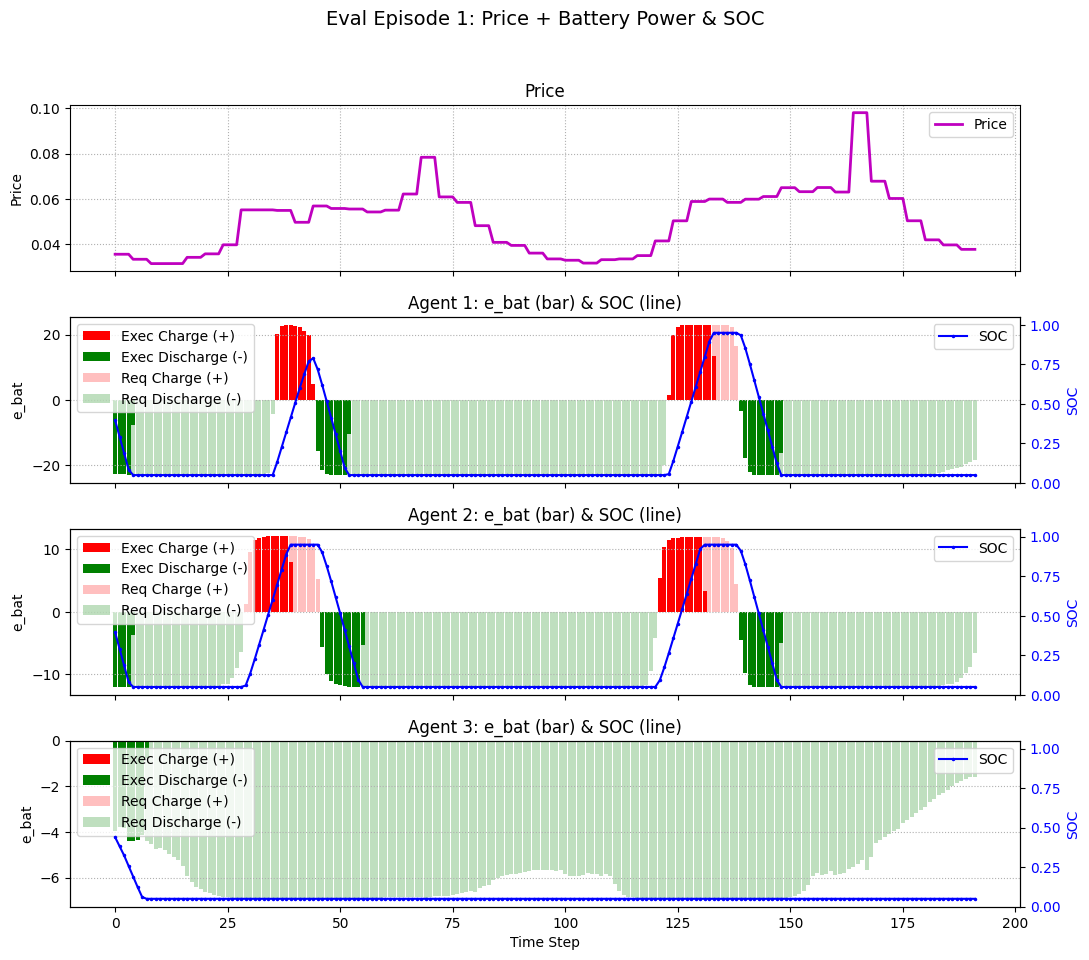

In [ ]:
eval_results = evaluate_runner(runner, cfg, n_episodes=n_eval_episodes, deterministic=True)
print("Mean evaluation reward =", eval_results["mean_episode_reward"])

eval_histories = eval_results.get("histories", [])
eval_window = min(reward_plot_window, max(1, len(eval_results["episode_rewards"])))

plot_reward_decomposition(
    history=runner.history,
    episode_rewards=runner.episode_rewards,
    reward_fn=plot_reward_fn,
    title="Training Reward Decomposition",
    window=reward_plot_window,
)

plot_last_k_episodes_price_action_soc(
    history=runner.history,
    k=n_recent_episodes_to_plot,
    n_agents=cfg.env.num_agents,
    title_prefix="Train",
)

plot_reward_decomposition(
    history=eval_histories,
    episode_rewards=eval_results["episode_rewards"],
    reward_fn=plot_reward_fn,
    title="Evaluation Reward Decomposition",
    window=eval_window,
)

plot_last_k_episodes_price_action_soc(
    history=eval_histories,
    k=min(n_recent_episodes_to_plot, len(eval_histories)),
    n_agents=cfg.env.num_agents,
    title_prefix="Eval",
)


In [ ]:
save_dir = get_madrl_checkpoint_root(project_root)
save_dir.mkdir(parents=True, exist_ok=True)
runner.save_model(str(save_dir), episode=episodes_completed)

final_summary = {
    "save_dir": str(save_dir),
    "saved_episode": int(episodes_completed),
    "mean_eval_reward": float(eval_results["mean_episode_reward"]),
    "perf_summary": runner.perf_summary,
}
print("模型已保存到 =", save_dir)
runner.close()
final_summary


模型已保存到 = D:\GithubProject\MADRL_ESS\artifacts\training\checkpoints


{'save_dir': 'D:\\GithubProject\\MADRL_ESS\\artifacts\\training\\checkpoints',
 'saved_episode': 8,
 'mean_eval_reward': -1635.1903011091053,
 'perf_summary': {'seed': 0,
  'runtime_mode': 'performance',
  'device': 'cuda:0',
  'total_wall_time_s': 17.31922940000004,
  'action_time_s': 1.3835581000057573,
  'env_step_time_s': 0.3020490000035352,
  'update_time_s': 15.436083500007953,
  'update_calls': 1409,
  'steps_per_sec': 88.68754865040337,
  'avg_action_ms_per_iter': 0.9007539713579149,
  'avg_env_ms_per_iter': 0.19664648437730156,
  'avg_update_ms_per_call': 10.955346699792727}}